# Lesson 5B-2: Stock Valuation, WACC, and Capital Structure

**Probability, Statistics and Econometrics for Finance, Accounting and Economics**  
**Instructor:** Matthew L. Kelly, PhD  
**Lesson sequence:** Finance valuation module, Part II

This notebook covers stock valuation, dividend discount models, free cash flow valuation, WACC, leverage, taxes, distress costs, and Modigliani-Miller capital structure theory.

## Learning objectives

By the end of this lecture, students should be able to:

1. Decompose stock returns into dividend yield and capital gain yield.
2. Derive constant-growth and multi-stage dividend discount models.
3. Connect the cost of equity to the CAPM.
4. Calculate WACC using market values of debt, preferred stock, and common equity.
5. Show how taxes and distress costs change the relation between leverage, WACC, and firm value.
6. State the Modigliani-Miller propositions formally and explain their intuition.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
np.set_printoptions(precision=4, suppress=True)
pd.options.display.float_format = "{:,.4f}".format


## 1. Stock returns: dividend yield plus capital gain yield

If a stock begins the period at price $P_0$, pays dividend $D_1$, and ends the period at price $P_1$, its one-period return is

$$
R = \frac{D_1 + P_1 - P_0}{P_0}.
$$

This decomposes into dividend yield and capital gain yield:

$$
R = \frac{D_1}{P_0} + \frac{P_1-P_0}{P_0}.
$$

The first term is income return. The second term is price appreciation.


In [2]:
P0, D1, P1 = 50, 2, 55
total_return = (D1 + P1 - P0) / P0
dividend_yield = D1 / P0
capital_gain_yield = (P1 - P0) / P0
print(f"Dividend yield: {dividend_yield:.2%}")
print(f"Capital gain yield: {capital_gain_yield:.2%}")
print(f"Total return: {total_return:.2%}")


Dividend yield: 4.00%
Capital gain yield: 10.00%
Total return: 14.00%


## 2. Dividend discount model: general form

The value of a share is the present value of expected future dividends:

$$
P_0 = \sum_{t=1}^{\infty}\frac{E_0[D_t]}{(1+r_e)^t},
$$

where $r_e$ is the required return on equity. This is just the present value formula applied to the cash flows stockholders receive.

If the investor sells the share at date $T$, the price at date $T$ is itself the present value of dividends after date $T$. So the infinite dividend valuation formula is consistent with finite holding periods.


## 3. Constant-growth dividend discount model

If next period's dividend is $D_1$ and dividends grow forever at constant rate $g$, then

$$
D_t = D_1(1+g)^{t-1}.
$$

The stock price is a growing perpetuity:

$$
P_0 = \sum_{t=1}^{\infty}\frac{D_1(1+g)^{t-1}}{(1+r_e)^t} = \frac{D_1}{r_e-g}, \qquad r_e>g.
$$

This also implies

$$
r_e = \frac{D_1}{P_0} + g.
$$

So the expected return equals dividend yield plus expected dividend growth.


In [3]:
def gordon_price(D1, re, g):
    if re <= g:
        raise ValueError('Required return must exceed growth rate.')
    return D1 / (re - g)

D1, re, g = 2.50, 0.10, 0.04
P0 = gordon_price(D1, re, g)
print(f"Constant-growth stock value: ${P0:,.2f}")
print(f"Dividend yield: {D1/P0:.2%}; growth: {g:.2%}; expected return: {D1/P0+g:.2%}")


Constant-growth stock value: $41.67
Dividend yield: 6.00%; growth: 4.00%; expected return: 10.00%


## 4. Multi-stage dividend growth

Many firms do not grow at one constant rate forever. A common model assumes high growth for a finite period followed by stable growth.

For $T$ years of explicit dividends and a terminal price at date $T$:

$$
P_0 = \sum_{t=1}^{T}\frac{D_t}{(1+r_e)^t} + \frac{P_T}{(1+r_e)^T},
$$

where

$$
P_T = \frac{D_{T+1}}{r_e-g_{stable}}.
$$


In [4]:
def multistage_ddm(D0, high_growth, stable_growth, re, high_growth_years):
    dividends = []
    D = D0
    for _ in range(high_growth_years):
        D *= (1 + high_growth)
        dividends.append(D)
    D_terminal_next = dividends[-1] * (1 + stable_growth)
    terminal_price = D_terminal_next / (re - stable_growth)
    pv_dividends = sum(Dt / (1 + re)**t for t, Dt in enumerate(dividends, start=1))
    pv_terminal = terminal_price / (1 + re)**high_growth_years
    return pv_dividends + pv_terminal, dividends, terminal_price

price, dividends, terminal_price = multistage_ddm(D0=1.50, high_growth=.12, stable_growth=.04, re=.10, high_growth_years=5)
print(f"Multi-stage DDM price: ${price:,.2f}")
print(f"Explicit dividends: {[round(d,2) for d in dividends]}")
print(f"Terminal price at year 5: ${terminal_price:,.2f}")


Multi-stage DDM price: $36.37
Explicit dividends: [1.68, 1.88, 2.11, 2.36, 2.64]
Terminal price at year 5: $45.82


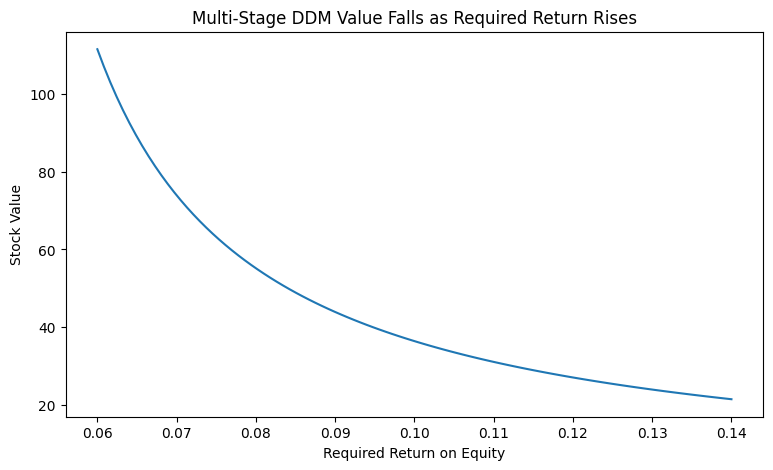

In [5]:
rates = np.linspace(.06, .14, 100)
prices = [multistage_ddm(1.50,.12,.04,r,5)[0] if r>.04 else np.nan for r in rates]
plt.figure(figsize=(9,5))
plt.plot(rates, prices)
plt.title('Multi-Stage DDM Value Falls as Required Return Rises')
plt.xlabel('Required Return on Equity')
plt.ylabel('Stock Value')
plt.show()


## 5. Cost of equity from CAPM

The CAPM says the expected return on equity is

$$
E[R_i] = R_f + \beta_i(E[R_M]-R_f),
$$

where

$$
\beta_i = \frac{Cov(R_i,R_M)}{Var(R_M)}.
$$

In corporate valuation, this expected return is often used as the cost of common equity:

$$
r_e = R_f + \beta_e \times \text{market risk premium}.
$$


In [6]:
rf = 0.04
beta_e = 1.20
market_risk_premium = 0.055
cost_of_equity = rf + beta_e * market_risk_premium
print(f"Cost of equity from CAPM: {cost_of_equity:.2%}")


Cost of equity from CAPM: 10.60%


## 6. Free cash flow valuation and enterprise value

Dividend discount models value equity directly. Free cash flow to the firm values the whole enterprise.

Free cash flow to the firm is often defined as

$$
FCFF = EBIT(1-T_c) + Depreciation - CapEx - \Delta NWC.
$$

Enterprise value is

$$
EV = \sum_{t=1}^{T}\frac{FCFF_t}{(1+WACC)^t} + \frac{TV_T}{(1+WACC)^T},
$$

with terminal value

$$
TV_T = \frac{FCFF_{T+1}}{WACC-g}.
$$

Equity value is then

$$
\text{Equity Value} = EV - \text{Market Value of Debt} - \text{Preferred Stock} + \text{Cash and Investments}.
$$


In [7]:
def fcff_valuation(fcff1, growth, wacc, terminal_growth, years):
    fcffs = [fcff1 * (1 + growth)**(t-1) for t in range(1, years+1)]
    tv = fcffs[-1] * (1 + terminal_growth) / (wacc - terminal_growth)
    pv_fcffs = sum(cf / (1 + wacc)**t for t, cf in enumerate(fcffs, start=1))
    pv_tv = tv / (1 + wacc)**years
    return pv_fcffs + pv_tv, fcffs, tv

EV, fcffs, tv = fcff_valuation(120, .06, .09, .03, 5)
print(f"Enterprise value: ${EV:,.2f} million")
print(f"Terminal value at year 5: ${tv:,.2f} million")


Enterprise value: $2,211.26 million
Terminal value at year 5: $2,600.70 million


## 7. WACC: using market values, not book values

The weighted average cost of capital is the expected return required by all capital providers, weighted by market values:

$$
WACC = \frac{E}{V}r_e + \frac{D}{V}r_d(1-T_c) + \frac{P}{V}r_p,
$$

where $E$ is market value of common equity, $D$ is market value of debt, $P$ is market value of preferred stock, and

$$
V = E + D + P.
$$

The after-tax cost of debt is $r_d(1-T_c)$ because interest is tax deductible.


## 8. Complete WACC example: common equity, bonds, taxes

Suppose Alpha Manufacturing has the following market information:

- Common shares outstanding: 50 million
- Market price per share: $40
- Equity beta: 1.15
- Risk-free rate: 4.0%
- Market risk premium: 5.5%
- Corporate tax rate: 25%
- Bond issue 1: $600 million market value, YTM 5.2%
- Bond issue 2: $400 million market value, YTM 6.0%

The cost of equity comes from CAPM. The cost of debt is the market-value weighted yield on the firm's debt.


In [8]:
shares_outstanding = 50_000_000
share_price = 40
E = shares_outstanding * share_price / 1_000_000  # in millions
beta_e = 1.15
rf = .04
mrp = .055
Tc = .25
re = rf + beta_e * mrp

debt = pd.DataFrame({
    'Issue': ['5-year notes', '10-year bonds'],
    'Market Value ($M)': [600, 400],
    'YTM': [.052, .060]
})
D = debt['Market Value ($M)'].sum()
rd = np.average(debt['YTM'], weights=debt['Market Value ($M)'])
V = E + D
wacc = E/V*re + D/V*rd*(1-Tc)

print(f"Market value of equity: ${E:,.1f}M")
print(debt)
print(f"Cost of equity: {re:.2%}")
print(f"Pre-tax cost of debt: {rd:.2%}")
print(f"After-tax cost of debt: {rd*(1-Tc):.2%}")
print(f"WACC: {wacc:.2%}")


Market value of equity: $2,000.0M
           Issue  Market Value ($M)    YTM
0   5-year notes                600 0.0520
1  10-year bonds                400 0.0600
Cost of equity: 10.33%
Pre-tax cost of debt: 5.52%
After-tax cost of debt: 4.14%
WACC: 8.26%


## 9. WACC example with debt maturities, preferred shares, and common shares

Preferred shares are usually valued like perpetuities. If preferred stock pays dividend $D_p$ and trades at price $P_p$, its required return is

$$
r_p = \frac{D_p}{P_p}.
$$

Now suppose a firm has two debt maturities, preferred shares, and common equity. The WACC is still just a market-value-weighted average of required returns.


In [9]:
capital = pd.DataFrame({
    'Capital Source': ['Short-term debt', 'Long-term debt', 'Preferred stock', 'Common equity'],
    'Market Value ($M)': [300, 700, 250, 2250],
    'Required Return': [.048, .062, .075, .105],
    'Tax Deductible?': [True, True, False, False]
})
Tc = .25
capital['After-Tax Required Return'] = np.where(capital['Tax Deductible?'], capital['Required Return']*(1-Tc), capital['Required Return'])
capital['Weight'] = capital['Market Value ($M)'] / capital['Market Value ($M)'].sum()
capital['WACC Contribution'] = capital['Weight'] * capital['After-Tax Required Return']
print(capital)
print(f"WACC: {capital['WACC Contribution'].sum():.2%}")


    Capital Source  Market Value ($M)  ...  Weight  WACC Contribution
0  Short-term debt                300  ...  0.0857             0.0031
1   Long-term debt                700  ...  0.2000             0.0093
2  Preferred stock                250  ...  0.0714             0.0054
3    Common equity               2250  ...  0.6429             0.0675

[4 rows x 7 columns]
WACC: 8.52%


## 10. Leverage, taxes, and the WACC

In a frictionless world without taxes, changing capital structure does not change total firm value. As debt increases, equity becomes riskier, so the cost of equity rises enough to offset the cheaper debt.

With corporate taxes, debt creates an interest tax shield. The value of a perpetual tax shield is approximately

$$
PV(\text{tax shield}) = T_c D.
$$

With expected distress costs, firm value can be written as

$$
V_L = V_U + T_cD - PV(\text{expected distress costs}).
$$

This tradeoff produces an interior optimal capital structure when the marginal tax benefit of debt equals the marginal expected distress cost.


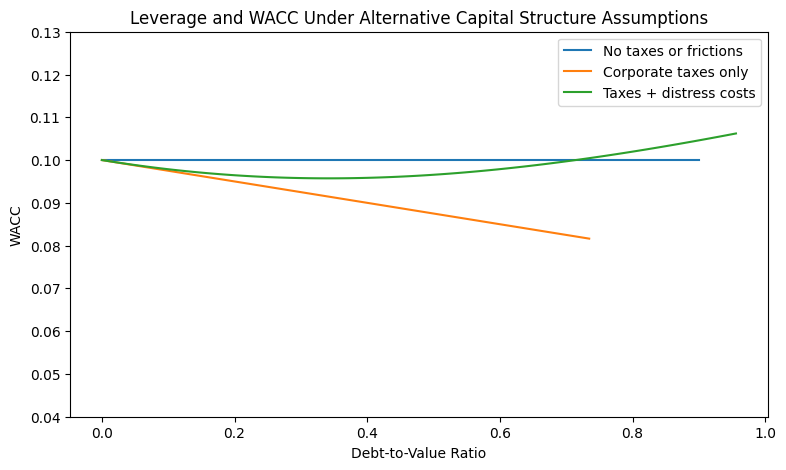

Tradeoff optimum debt: $354.5M
Debt/value at optimum: 33.94%
Minimum implied WACC: 9.57%


In [10]:
VU = 1000
ru = 0.10
rd = 0.05
Tc = 0.25
D_values = np.linspace(0, 900, 100)

# No taxes/frictions: V constant; equity cost adjusts.
V_no_tax = np.full_like(D_values, VU)
E_no_tax = V_no_tax - D_values
re_no_tax = ru + (ru-rd) * D_values / np.maximum(E_no_tax, 1e-9)
wacc_no_tax = E_no_tax/V_no_tax*re_no_tax + D_values/V_no_tax*rd

# Taxes only.
V_tax = VU + Tc * D_values
E_tax = V_tax - D_values
re_tax = ru + (ru-rd)*(1-Tc)*D_values / np.maximum(E_tax, 1e-9)
wacc_tax = E_tax/V_tax*re_tax + D_values/V_tax*rd*(1-Tc)

# Taxes plus convex distress costs.
distress_cost = 0.00035 * D_values**2
V_tradeoff = VU + Tc*D_values - distress_cost
E_tradeoff = V_tradeoff - D_values
wacc_tradeoff = ru * VU / V_tradeoff  # implied by EV = FCFF/WACC with constant FCFF

plt.figure(figsize=(9,5))
plt.plot(D_values/V_no_tax, wacc_no_tax, label='No taxes or frictions')
plt.plot(D_values/V_tax, wacc_tax, label='Corporate taxes only')
plt.plot(D_values/np.maximum(V_tradeoff,1e-9), wacc_tradeoff, label='Taxes + distress costs')
plt.title('Leverage and WACC Under Alternative Capital Structure Assumptions')
plt.xlabel('Debt-to-Value Ratio')
plt.ylabel('WACC')
plt.ylim(0.04, 0.13)
plt.legend()
plt.show()

optimal_idx = np.nanargmin(wacc_tradeoff)
print(f"Tradeoff optimum debt: ${D_values[optimal_idx]:,.1f}M")
print(f"Debt/value at optimum: {D_values[optimal_idx]/V_tradeoff[optimal_idx]:.2%}")
print(f"Minimum implied WACC: {wacc_tradeoff[optimal_idx]:.2%}")


## 11. Leverage and the cost of equity

Modigliani-Miller Proposition II says leverage increases the required return on equity because debt makes residual equity cash flows riskier.

Without taxes:

$$
r_e = r_A + (r_A-r_D)\frac{D}{E}.
$$

With corporate taxes:

$$
r_e = r_A + (r_A-r_D)(1-T_c)\frac{D}{E}.
$$

The core intuition is that leverage does not eliminate risk. It reallocates risk between debt and equity holders.


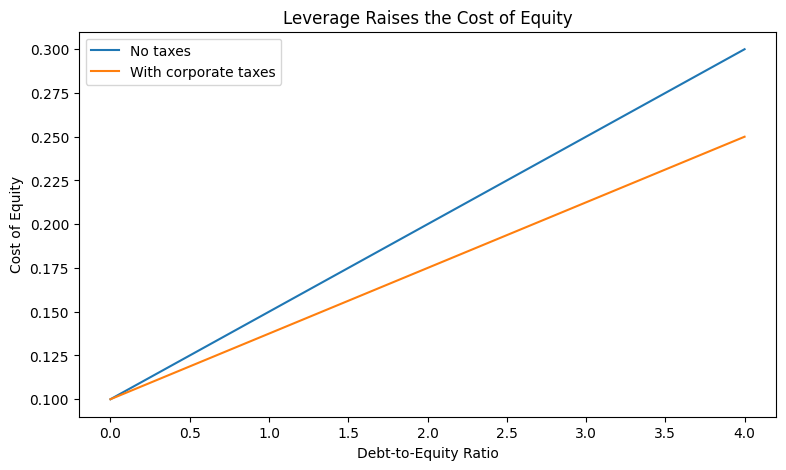

In [11]:
DE = np.linspace(0, 4, 100)
rA = .10
rD = .05
Tc = .25
re_notax = rA + (rA-rD)*DE
re_tax = rA + (rA-rD)*(1-Tc)*DE
plt.figure(figsize=(9,5))
plt.plot(DE, re_notax, label='No taxes')
plt.plot(DE, re_tax, label='With corporate taxes')
plt.title('Leverage Raises the Cost of Equity')
plt.xlabel('Debt-to-Equity Ratio')
plt.ylabel('Cost of Equity')
plt.legend()
plt.show()


## 12. DCF with WACC: a complete valuation example

Assume Alpha Manufacturing has projected free cash flow to the firm of $180 million next year, expected to grow at 6% for five years and then 3% forever. We use the WACC from the earlier common-equity-and-bond example.

After computing enterprise value, subtract debt and add cash to obtain equity value.


In [12]:
fcff1 = 180
growth = .06
terminal_growth = .03
EV, fcffs, terminal = fcff_valuation(fcff1, growth, wacc, terminal_growth, 5)
cash = 150
equity_value = EV - D + cash
value_per_share = equity_value * 1_000_000 / shares_outstanding
print(f"Enterprise value: ${EV:,.2f}M")
print(f"Less market debt: ${D:,.2f}M")
print(f"Add cash: ${cash:,.2f}M")
print(f"Equity value: ${equity_value:,.2f}M")
print(f"Estimated value per share: ${value_per_share:,.2f}")


Enterprise value: $3,787.23M
Less market debt: $1,000.00M
Add cash: $150.00M
Equity value: $2,937.23M
Estimated value per share: $58.74


In [13]:
wacc_grid = np.linspace(.07, .11, 5)
g_grid = np.linspace(.02, .04, 5)
sens = pd.DataFrame(index=[f'{g:.1%}' for g in g_grid], columns=[f'{w:.1%}' for w in wacc_grid])
for gterm in g_grid:
    for w in wacc_grid:
        EV_tmp, _, _ = fcff_valuation(fcff1, growth, w, gterm, 5)
        eq_tmp = EV_tmp - D + cash
        sens.loc[f'{gterm:.1%}', f'{w:.1%}'] = eq_tmp * 1_000_000 / shares_outstanding
print('Value per share sensitivity table')
print(sens.astype(float))


Value per share sensitivity table
         7.0%    8.0%    9.0%   10.0%   11.0%
2.0%  65.6164 51.6450 41.6717 34.1970 28.3878
2.5%  73.3215 56.7066 45.2099 36.7839 30.3445
3.0%  82.9528 62.7805 49.3378 39.7403 32.5459
3.5%  95.3360 70.2042 54.2162 43.1515 35.0408
4.0% 111.8470 79.4838 60.0702 47.1313 37.8921


## 13. Formal Modigliani-Miller statements

### Proposition I, no taxes

In perfect capital markets, firm value is independent of capital structure:

$$
V_L = V_U.
$$

Leverage changes the division of claims between debt and equity, but it does not change the size of the pie.

### Proposition II, no taxes

The expected return on levered equity rises linearly with leverage:

$$
r_E = r_A + (r_A-r_D)\frac{D}{E}.
$$

### Proposition I, corporate taxes

With corporate taxes and interest deductibility,

$$
V_L = V_U + T_cD.
$$

### Proposition II, corporate taxes

With taxes, the cost of levered equity is

$$
r_E = r_A + (r_A-r_D)(1-T_c)\frac{D}{E}.
$$

### Tradeoff theory

Once distress costs, agency costs, and transaction costs are introduced, firm value becomes

$$
V_L = V_U + PV(\text{tax shields}) - PV(\text{expected distress and agency costs}).
$$

The optimal capital structure balances the marginal tax benefit of debt against the marginal expected cost of financial distress.


## 14. Summary

Stock valuation and corporate valuation are applications of present value. Dividend discount models value equity cash flows directly. FCFF valuation values the enterprise and then subtracts non-equity claims. WACC connects valuation to capital structure because it is the weighted opportunity cost of the firm's capital providers.

Modigliani-Miller clarifies what capital structure can and cannot do. In frictionless markets, leverage cannot create value by itself. Taxes can make debt valuable, but distress costs and other frictions limit the amount of debt firms should use.
